# Phase 1: Exploratory Data Analysis (EDA)
## Amazon ML Challenge 2026 - Business Entity Resolution

This notebook presents the exploratory data analysis across all training and test files, ground truth matching distributions, noise patterns, and architectural scale implications.


In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load precomputed EDA statistics
with open("../experiments/eda_statistics.json", "r") as f:
    eda_stats = json.load(f)

with open("../experiments/noise_pattern_examples.json", "r") as f:
    noise_examples = json.load(f)


### 1. Dataset File Sizes, Row Counts & Schemas

In [2]:
rows = []
for fname, s in eda_stats["sources"].items():
    rows.append({
        "Source File": fname,
        "Total Rows": f"{s['total_rows']:,}",
        "Duplicate IDs": s["duplicate_ids"],
        "Missing Names": s["missing_values"]["business_name"],
        "Missing Addr": f"{s['missing_values']['business_address']:,}",
        "Missing Country": s["missing_values"]["country"],
        "Countries": str(s["country_distribution"])
    })

pd.DataFrame(rows)


,Source File,Total Rows,Duplicate IDs,Missing Names,Missing Addr,Missing Country,Countries
0,train_source1,"2,206,821",0,0,0,0,"{'US': 1323633, 'India': 883188}"
1,train_source2,"5,034,616",0,0,"168,967",0,"{'US': 3016817, 'India': 2017799}"
2,train_source3,"5,285,603",0,0,"175,916",0,"{'US': 3170056, 'India': 2115547}"
3,test_source1,"1,732,544",0,0,0,0,"{'India': 809986, 'US': 663106, 'France': 259452}"
4,test_source2,"4,887,273",0,0,"129,408",0,"{'India': 2312565, 'US': 1871330, 'France': 70..."
5,test_source3,"5,082,316",0,0,"136,098",0,"{'India': 2405000, 'US': 1945701, 'France': 73..."


### 2. Country Distributions across Training and Test
Notice that training contains US and India (~60/40), while test contains India (~47.3%), US (~38.3%), and France (~14.4%).


In [3]:
ctry_data = []
for fname, s in eda_stats["sources"].items():
    cdist = s["country_distribution"]
    tot = s["total_rows"]
    row = {"Dataset": fname}
    for c, cnt in cdist.items():
        row[c] = f"{cnt:,} ({cnt/tot*100:.1f}%)"
    ctry_data.append(row)

pd.DataFrame(ctry_data).fillna("-")


,Dataset,US,India,France
0,train_source1,"1,323,633 (60.0%)","883,188 (40.0%)",-
1,train_source2,"3,016,817 (59.9%)","2,017,799 (40.1%)",-
2,train_source3,"3,170,056 (60.0%)","2,115,547 (40.0%)",-
3,test_source1,"663,106 (38.3%)","809,986 (46.8%)","259,452 (15.0%)"
4,test_source2,"1,871,330 (38.3%)","2,312,565 (47.3%)","703,378 (14.4%)"
5,test_source3,"1,945,701 (38.3%)","2,405,000 (47.3%)","731,615 (14.4%)"


### 3. Ground Truth Matching Statistics
Key insights:
- Singletons (0 matches): 123,247 (5.58%)
- Matched entities: 2,083,574 (94.42%)
- Cross-country matches: Exactly 0 (100% within-country)
- S2/S3 entities matching multiple S1s: Exactly 0 (Strict 1-to-1 matching from S2/S3 to S1)


In [4]:
gt = eda_stats["ground_truth"]
print(f"Total S1 entities: {gt['total_source1_entities']:,}")
print(f"Singletons: {gt['singletons_count']:,} ({gt['singletons_percentage']}%)")
print(f"Non-singletons: {gt['non_singletons_count']:,} ({gt['non_singletons_percentage']}%)")
print(f"Both S2 and S3 matched: {gt['both_s2_and_s3_count']:,}")
print(f"S2 only matched: {gt['s2_only_count']:,}")
print(f"S3 only matched: {gt['s3_only_count']:,}")
print(f"Unique S2 matched: {gt['total_unique_s2_matched']:,}")
print(f"Unique S3 matched: {gt['total_unique_s3_matched']:,}")
print(f"S2 matching multiple S1: {gt['s2_entities_matching_multiple_s1']}")
print(f"S3 matching multiple S1: {gt['s3_entities_matching_multiple_s1']}")


Total S1 entities: 2,206,821
Singletons: 123,247 (5.5848%)
Non-singletons: 2,083,574 (94.4152%)
Both S2 and S3 matched: 1,776,047
S2 only matched: 143,029
S3 only matched: 164,498
Unique S2 matched: 3,693,619
Unique S3 matched: 3,944,746
S2 matching multiple S1: 0
S3 matching multiple S1: 0


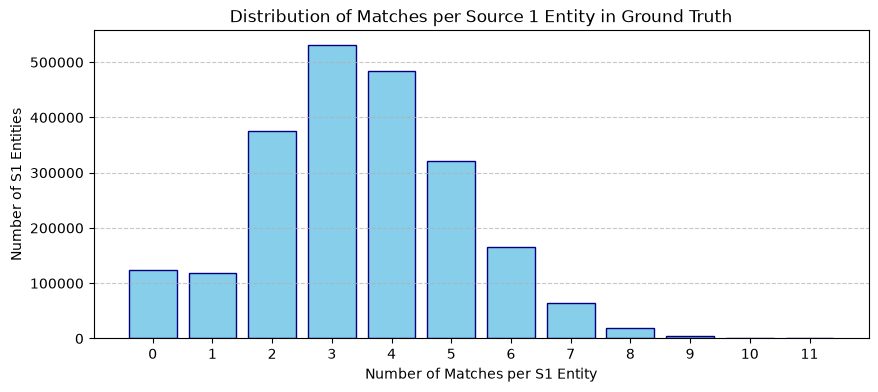

In [5]:
match_dist = gt["match_count_distribution"]
plt.figure(figsize=(10, 4))
plt.bar([int(k) for k in match_dist.keys()], match_dist.values(), color="skyblue", edgecolor="navy")
plt.xlabel("Number of Matches per S1 Entity")
plt.ylabel("Number of S1 Entities")
plt.title("Distribution of Matches per Source 1 Entity in Ground Truth")
plt.xticks(range(12))
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


### 4. Qualitative Noise Patterns & Real Examples

In [6]:
for cat, samples in noise_examples.items():
    print(f"=== Category: {cat} (found {len(samples)} examples) ===")
    if samples:
        s = samples[0]
        if "s1_name" in s:
            print(f"  S1: [{s['s1_name']}] | [{s['s1_address']}] ({s['country']})")
            print(f"  Match: [{s['target_name']}] | [{s['target_address']}]")
        elif "entity_1" in s:
            print(f"  E1: [{s['entity_1']['name']}] | [{s['entity_1']['address']}]")
            print(f"  E2: [{s['entity_2']['name']}] | [{s['entity_2']['address']}]")
    print()


=== Category: exact_matches (found 5 examples) ===
  S1: [Raj Investments LLP] | [6(29), C.I.T. Colony, 2Nd Main Road Mylapore, Chennai, Tamil Nadu] (India)
  Match: [Raj Investments LLP] | [6(29), C.I.T. COLONY, 2ND MAIN ROAD MYLAPORE, CHENNAI, Tamil Nadu]

=== Category: legal_suffix_differences (found 5 examples) ===
  S1: [Maure Williams Colombier Inc] | [85 Wayne Avenue, Ticonderoga, NY] (US)
  Match: [Maure Williams Colombier] | []

=== Category: abbreviation_differences (found 0 examples) ===

=== Category: punctuation_differences (found 5 examples) ===
  S1: [Blankenship and Russo Inc] | [1339 E Street, Unit 306, Washington, DC] (US)
  Match: [Blankenship & Rnsumo Inc] | [1339 E ST, WASHINGTON, DC]

=== Category: typos (found 0 examples) ===

=== Category: word_order_differences (found 5 examples) ===
  S1: [Hendricks and Flowers Inc] | [33 Sleepy Hollow Drive, Danbury, CT] (US)
  Match: [Hendricks and  Flowers Inc] | [CT, SLEEPY HOLLOW DRIVE, DANBURY]

=== Category: translitera